# 5개 모델 블라인드 추론 비교

학습에 사용하지 않은 외부 DWG → 5개 모델 각각 추론 → 결과 비교.
파일명 정보는 예측에 일절 사용하지 않음.

In [1]:
import os, sys, json, math, subprocess, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

import ezdxf
from ezdxf import bbox as ezdxf_bbox
from ezdxf.units import decode as decode_unit

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT  = Path('/Users/gimdabin/SKN23-FINAL-2TEAM')
TEST_DWG_DIR  = Path('/Users/gimdabin/Library/CloudStorage/GoogleDrive-superkdb0918@gmail.com/내 드라이브/DWG/test')
TEMP_DXF_DIR  = PROJECT_ROOT / 'temp_dxf' / 'inference_test'
TEMP_JSON_DIR = PROJECT_ROOT / 'temp_dxf' / 'inference_json'
MODEL_DIR     = PROJECT_ROOT / 'backend' / 'classifier_models'
ALL_MODELS_DIR = MODEL_DIR / 'all_models'
ODA_EXE       = Path('/Applications/ODAFileConverter.app/Contents/MacOS/ODAFileConverter')

TEMP_DXF_DIR.mkdir(parents=True, exist_ok=True)
TEMP_JSON_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

# all_models/ 폴더 확인
pkl_files = sorted(ALL_MODELS_DIR.glob('*.pkl')) if ALL_MODELS_DIR.exists() else []
print(f'사용 가능한 모델 pkl: {len(pkl_files)}개')
for p in pkl_files:
    print(f'  {p.name}')

print(f'\nODA: {ODA_EXE}  존재={ODA_EXE.exists()}')
print(f'테스트 DWG 폴더: {TEST_DWG_DIR}  존재={TEST_DWG_DIR.exists()}')


사용 가능한 모델 pkl: 6개
  catboost.pkl
  gradient_boosting.pkl
  logistic_regression.pkl
  mlp.pkl
  random_forest.pkl
  svm.pkl

ODA: /Applications/ODAFileConverter.app/Contents/MacOS/ODAFileConverter  존재=True
테스트 DWG 폴더: /Users/gimdabin/Library/CloudStorage/GoogleDrive-superkdb0918@gmail.com/내 드라이브/DWG/test  존재=True


le   = joblib.load(MODEL_DIR / 'label_encoder.pkl')
meta = json.loads((MODEL_DIR / 'domain_classifier_meta.json').read_text())

DISPLAY_NAME = {
    'random_forest':       'RandomForest',
    'gradient_boosting':   'GradientBoosting',
    'svm':                 'SVM',
    'catboost':            'CatBoost',
    'logistic_regression': 'LogisticRegression',
    'mlp':                 'MLP',
}

models = {}
for pkl_path in sorted(ALL_MODELS_DIR.glob('*.pkl')):
    key  = pkl_path.stem
    name = DISPLAY_NAME.get(key, key)
    models[name] = joblib.load(pkl_path)

# ── CV 수치 테이블 ──
rows = []
for name, cv in meta['all_cv_models'].items():
    rows.append({
        '모델':          name,
        'CV MacroF1':    round(cv['macro_f1_mean'], 4),
        'CV F1 ± std':   f"{cv['macro_f1_mean']:.4f} ± {cv['macro_f1_std']:.4f}",
        'CV Accuracy':   round(cv['accuracy_mean'], 4),
    })

cv_df = pd.DataFrame(rows).sort_values('CV MacroF1', ascending=False)
print('=== CV 학습 성능 (10-Fold Stratified) ===')
print(cv_df[['모델','CV F1 ± std','CV Accuracy']].to_string(index=False))
print(f'\n클래스: {le.classes_.tolist()}')
print(f'학습 샘플: {meta["n_samples"]}개  피처: {meta["n_features"]}차원')


In [2]:
le = joblib.load(MODEL_DIR / 'label_encoder.pkl')
meta = json.loads((MODEL_DIR / 'domain_classifier_meta.json').read_text())

# 표시용 이름 매핑
DISPLAY_NAME = {
    'random_forest':       'RandomForest',
    'gradient_boosting':   'GradientBoosting',
    'svm':                 'SVM',
    'catboost':            'CatBoost',
    'logistic_regression': 'LogisticRegression',
    'mlp':                 'MLP',
}

models = {}
for pkl_path in sorted(ALL_MODELS_DIR.glob('*.pkl')):
    key = pkl_path.stem
    name = DISPLAY_NAME.get(key, key)
    model = joblib.load(pkl_path)
    cv_info = meta['all_cv_models'].get(name, {})
    models[name] = model
    print(f'[로드] {name:<22}  CV MacroF1={cv_info.get("macro_f1_mean", 0):.4f}  '
          f'n_features={model.n_features_in_}')

print(f'\n총 {len(models)}개 모델 로드 완료')
print(f'클래스: {le.classes_.tolist()}')


[로드] CatBoost                CV MacroF1=0.9270  n_features=83
[로드] GradientBoosting        CV MacroF1=0.9332  n_features=83
[로드] LogisticRegression      CV MacroF1=0.8209  n_features=83
[로드] MLP                     CV MacroF1=0.8831  n_features=83
[로드] RandomForest            CV MacroF1=0.9299  n_features=83
[로드] SVM                     CV MacroF1=0.9212  n_features=83

총 6개 모델 로드 완료
클래스: ['arch', 'elec', 'fire', 'pipe']


## 2. DXF → JSON 파싱 함수

In [3]:
def _pt(p):
    return {'x': round(float(p[0]),4), 'y': round(float(p[1]),4)}

def _get_bbox(entity):
    try:
        ext = ezdxf_bbox.extents([entity])
        if ext and ext.extmin is not None:
            return {'x1':round(ext.extmin.x,4),'y1':round(ext.extmin.y,4),
                    'x2':round(ext.extmax.x,4),'y2':round(ext.extmax.y,4)}
    except: pass
    return None

def _get_unit(doc):
    insunits = doc.header.get('$INSUNITS', 0)
    m = {1:'inch',2:'unknown',4:'mm',5:'unknown',6:'m'}
    if insunits in m: return m[insunits]
    try:
        info = decode_unit(insunits)
        raw = info.name.lower() if hasattr(info,'name') else str(info).lower()
        return raw if raw in ('mm','inch','m') else 'unknown'
    except: return 'unknown'

def _build_entity(ent):
    etype = ent.dxftype()
    SUPPORTED = {'LINE','ARC','CIRCLE','LWPOLYLINE','POLYLINE','SPLINE','ELLIPSE',
                 'INSERT','MTEXT','TEXT','DIMENSION','HATCH','SOLID','MLEADER'}
    if etype not in SUPPORTED: return None
    bbox = _get_bbox(ent)
    if bbox is None: return None
    d = {'handle':ent.dxf.handle,'type':etype if etype!='INSERT' else 'BLOCK',
         'layer':ent.dxf.layer,'bbox':bbox}
    try:
        ci = ent.dxf.color
        d['color']='BYLAYER' if ci==256 else ('BYBLOCK' if ci==0 else str(ci))
    except: d['color']='BYLAYER'
    try: d['linetype']=ent.dxf.linetype
    except: d['linetype']=None
    try:
        lw=ent.dxf.lineweight
        d['lineweight']='BYLAYER' if lw==-1 else ('BYBLOCK' if lw==-2 else f'{lw/100:.2f}mm')
    except: d['lineweight']='BYLAYER'
    try:
        if etype=='LINE':
            s,e=ent.dxf.start,ent.dxf.end
            d['start']=_pt(s);d['end']=_pt(e)
            d['length']=round(math.hypot(e.x-s.x,e.y-s.y),4)
        elif etype=='CIRCLE':
            d['center']=_pt(ent.dxf.center);d['radius']=round(ent.dxf.radius,4)
            d['diameter']=round(ent.dxf.radius*2,4)
        elif etype=='ARC':
            d['center']=_pt(ent.dxf.center);d['radius']=round(ent.dxf.radius,4)
            d['start_angle']=round(ent.dxf.start_angle,4);d['end_angle']=round(ent.dxf.end_angle,4)
        elif etype in ('LWPOLYLINE','POLYLINE'):
            d['type']='POLYLINE'
            verts=[]
            if etype=='LWPOLYLINE':
                for v in ent.get_points('xyb'):
                    verts.append({'x':round(v[0],4),'y':round(v[1],4),'bulge':round(v[2],6)})
            else:
                for v in ent.vertices:
                    pt=v.dxf.location; verts.append({'x':round(pt.x,4),'y':round(pt.y,4),'bulge':0.0})
            d['vertices']=verts; d['is_closed']=bool(ent.is_closed)
        elif etype=='INSERT':
            d['block_name']=ent.dxf.name; d['insert_point']=_pt(ent.dxf.insert)
        elif etype=='MTEXT':
            d['text']=ent.text; d['insert_point']=_pt(ent.dxf.insert)
            d['text_height']=round(ent.dxf.char_height,4)
        elif etype=='TEXT':
            try: d['text']=ent.dxf.text
            except: d['text']=''
            d['insert_point']=_pt(ent.dxf.insert); d['text_height']=round(ent.dxf.height,4)
        elif etype=='DIMENSION':
            try: d['measurement']=round(ent.dxf.actual_measurement,4)
            except: d['measurement']=0
        elif etype=='HATCH':
            d['pattern_name']=ent.dxf.pattern_name
    except: pass
    return d

def dxf_to_cad_dict(dxf_path: Path) -> dict:
    doc = ezdxf.readfile(str(dxf_path))
    msp = doc.modelspace()
    unit = _get_unit(doc)
    layer_cnt = {}
    for ent in msp:
        ln=ent.dxf.layer; layer_cnt[ln]=layer_cnt.get(ln,0)+1
    layers = []
    for layer in doc.layers:
        name=layer.dxf.name
        lw=layer.dxf.get('lineweight',-1)
        lw_s='BYLAYER' if lw==-1 else ('BYBLOCK' if lw==-2 else f'{lw/100:.2f}mm')
        layers.append({'name':name,'entity_count':layer_cnt.get(name,0),
                       'is_on':layer.is_on(),'is_locked':layer.is_locked(),
                       'color':str(layer.dxf.color),'linetype':layer.dxf.linetype,
                       'lineweight':lw_s,'is_plottable':layer.dxf.get('plot',True)})
    entities=[e for ent in msp if (e:=_build_entity(ent)) is not None]
    return {'drawing_name':dxf_path.stem,'drawing_unit':unit,
            'layer_count':len(layers),'entity_count':len(entities),
            'layers':layers,'entities':entities}

print('파싱 함수 정의 완료')


파싱 함수 정의 완료


## 3. DWG → DXF 변환 (ODA)

In [4]:
dwg_files = sorted(TEST_DWG_DIR.glob('*.dwg'))
print(f'테스트 DWG: {len(dwg_files)}개')

existing = list(TEMP_DXF_DIR.glob('*.dxf'))
if len(existing) >= len(dwg_files):
    print(f'[SKIP] DXF {len(existing)}개 이미 존재 — 변환 생략')
elif not ODA_EXE.exists():
    print('⚠️  ODA File Converter 없음')
else:
    cmd = [str(ODA_EXE), str(TEST_DWG_DIR), str(TEMP_DXF_DIR), 'ACAD2018', 'DXF', '1', '1']
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
    dxf_now = list(TEMP_DXF_DIR.glob('*.dxf'))
    print(f'변환 완료: {len(dxf_now)}개 DXF 생성')

dxf_files = sorted(TEMP_DXF_DIR.glob('*.dxf'))
print(f'\n사용할 DXF: {len(dxf_files)}개')
for f in dxf_files:
    print(f'  {f.name}')


테스트 DWG: 33개
[SKIP] DXF 33개 이미 존재 — 변환 생략

사용할 DXF: 33개
  건축_01.dxf
  건축_02.dxf
  건축_03.dxf
  건축_04.dxf
  건축_05.dxf
  건축_06.dxf
  건축_07.dxf
  건축_08.dxf
  배관_01.dxf
  배관_02.dxf
  배관_03.dxf
  배관_04.dxf
  배관_05.dxf
  배관_06.dxf
  배관_07.dxf
  배관_08.dxf
  소방_01.dxf
  소방_02.dxf
  소방_03.dxf
  소방_04.dxf
  소방_05.dxf
  소방_06.dxf
  소방_07.dxf
  소방_08.dxf
  소방_09.dxf
  전기_01.dxf
  전기_02.dxf
  전기_05.dxf
  전기_06.dxf
  전기_07.dxf
  전기_08.dxf
  전기_09.dxf
  전기_10.dxf


## 4. DXF → JSON 파싱

In [5]:
from backend.services.agents.common.domain_classifier.feature_extractor import (
    extract_features, get_feature_dim
)

cad_records = []  # {'filename': str, 'cad': dict, 'feat': ndarray}

print(f'피처 차원: {get_feature_dim()}')
print()

for dxf_path in dxf_files:
    stem = unicodedata.normalize('NFC', dxf_path.stem)
    json_path = TEMP_JSON_DIR / f'{stem}.json'

    try:
        if json_path.exists():
            with open(json_path, encoding='utf-8') as f:
                cad = json.load(f)
            status = 'CACHE'
        else:
            cad = dxf_to_cad_dict(dxf_path)
            with open(json_path, 'w', encoding='utf-8') as f:
                json.dump(cad, f, ensure_ascii=False)
            status = 'PARSE'

        feat = extract_features(cad)
        cad_records.append({'filename': stem, 'cad': cad, 'feat': feat})
        print(f'[{status}] {stem:<22}  layers={cad["layer_count"]:3d}  entities={cad["entity_count"]:5d}')

    except Exception as e:
        print(f'[FAIL]  {stem}: {e}')

print(f'\n총 {len(cad_records)}개 파싱 완료')


피처 차원: 83

[CACHE] 건축_01                   layers= 36  entities= 3586
[CACHE] 건축_02                   layers=  9  entities= 1974
[CACHE] 건축_03                   layers= 62  entities= 3700
[CACHE] 건축_04                   layers= 34  entities= 5391
[CACHE] 건축_05                   layers= 34  entities= 5391
[CACHE] 건축_06                   layers= 48  entities= 4268
[CACHE] 건축_07                   layers= 27  entities= 1666
[CACHE] 건축_08                   layers= 11  entities= 5806
[CACHE] 배관_01                   layers= 12  entities=   36
[CACHE] 배관_02                   layers= 11  entities=  702
[CACHE] 배관_03                   layers=135  entities=16782
[CACHE] 배관_04                   layers=135  entities=16782
[CACHE] 배관_05                   layers= 78  entities=  740
[CACHE] 배관_06                   layers= 48  entities= 3320
[CACHE] 배관_07                   layers= 15  entities= 1231
[CACHE] 배관_08                   layers= 15  entities= 1301
[CACHE] 소방_01                   layers= 27  e

# 파일명 prefix → 정답 도메인 (블라인드 추론이지만 평가용으로 별도 보관)
TRUE_LABEL_MAP = {'건축':'arch', '배관':'pipe', '소방':'fire', '전기':'elec'}

inference_rows = []

for rec in cad_records:
    stem     = rec['filename']
    feat_full = rec['feat']

    # 정답 추출 (평가용)
    true_domain = next((v for k, v in TRUE_LABEL_MAP.items() if stem.startswith(k)), 'unknown')

    row = {'파일명': stem, '정답': true_domain}

    for model_name, model_obj in models.items():
        feat = feat_full[:model_obj.n_features_in_].reshape(1, -1)
        try:
            pred  = le.inverse_transform(model_obj.predict(feat))[0]
            proba = model_obj.predict_proba(feat)[0]
            conf  = float(proba.max())
        except Exception:
            pred, conf = 'ERR', 0.0
        row[model_name]             = pred
        row[f'{model_name}_conf']   = round(conf, 3)
        row[f'{model_name}_correct'] = (pred == true_domain)

    inference_rows.append(row)

df = pd.DataFrame(inference_rows)
model_names = list(models.keys())

# ── 블라인드 추론 정확도 계산 ──
domains = ['arch', 'pipe', 'fire', 'elec']
perf_rows = []

for model_name in model_names:
    cv_info = meta['all_cv_models'].get(model_name, {})
    r = {
        '모델':         model_name,
        'CV MacroF1':   f"{cv_info.get('macro_f1_mean',0):.4f} ± {cv_info.get('macro_f1_std',0):.4f}",
        'CV Accuracy':  f"{cv_info.get('accuracy_mean',0):.4f}",
    }
    total_correct = 0
    for d in domains:
        sub = df[df['정답'] == d]
        n   = len(sub)
        c   = sub[f'{model_name}_correct'].sum()
        r[f'{d} ({n}개)'] = f'{c}/{n} ({c/n:.0%})' if n > 0 else '-'
        total_correct += c
    total = len(df)
    r['블라인드 전체'] = f'{total_correct}/{total} ({total_correct/total:.1%})'
    perf_rows.append(r)

perf_df = pd.DataFrame(perf_rows).sort_values(
    '블라인드 전체',
    key=lambda x: x.str.extract(r'(\d+\.\d+)%')[0].astype(float),
    ascending=False
)

print('=== 블라인드 추론 결과 (정답 대조) ===')
print()
print(perf_df.to_string(index=False))
print()

# 단순 예측값 테이블
print('=== 파일별 예측 도메인 ===')
print(df[['파일명','정답'] + model_names].to_string(index=False))


In [6]:
# 각 모델별 추론 결과를 모아서 비교
inference_rows = []

for rec in cad_records:
    feat_full = rec['feat']
    row = {'파일명': rec['filename']}

    for model_name, model_obj in models.items():
        n_feat = model_obj.n_features_in_
        feat = feat_full[:n_feat].reshape(1, -1)
        try:
            pred_enc = model_obj.predict(feat)
            pred = le.inverse_transform(pred_enc)[0]
            proba = model_obj.predict_proba(feat)[0]
            conf = float(proba.max())
        except Exception as e:
            pred = 'ERR'
            conf = 0.0
        row[model_name] = pred
        row[f'{model_name}_conf'] = round(conf, 3)

    inference_rows.append(row)

df = pd.DataFrame(inference_rows)

# 예측 결과만 보기 쉽게 출력
model_names = list(models.keys())
print('=== 블라인드 추론 결과 ===')
print()
display_cols = ['파일명'] + model_names
print(df[display_cols].to_string(index=False))

# 모델 간 합의율
print()
def consensus(row):
    preds = [row[m] for m in model_names]
    from collections import Counter
    most_common, cnt = Counter(preds).most_common(1)[0]
    return f'{most_common} ({cnt}/{len(model_names)})'

df['합의'] = df.apply(consensus, axis=1)
print('=== 합의 결과 ===')
print(df[['파일명','합의']].to_string(index=False))


=== 블라인드 추론 결과 ===

  파일명 CatBoost GradientBoosting LogisticRegression  MLP RandomForest  SVM
건축_01     pipe             pipe               pipe pipe         arch pipe
건축_02     pipe             pipe               arch arch         pipe pipe
건축_03     arch             pipe               fire arch         arch arch
건축_04     arch             arch               arch arch         arch arch
건축_05     arch             arch               arch arch         arch arch
건축_06     arch             arch               arch fire         arch arch
건축_07     arch             arch               arch arch         arch arch
건축_08     arch             pipe               arch arch         pipe arch
배관_01     fire             pipe               arch pipe         pipe pipe
배관_02     pipe             pipe               elec pipe         pipe pipe
배관_03     fire             fire               fire fire         fire fire
배관_04     fire             fire               fire fire         fire fire
배관_05     pipe    

DOMAIN_COLORS = {'arch':'#2196F3','elec':'#FF9800','fire':'#F44336','pipe':'#4CAF50','ERR':'#9E9E9E'}
DOMAIN_LABEL  = {'arch':'건축','pipe':'배관','fire':'소방','elec':'전기'}

# ── 1) 파일×모델 예측 그리드 (정답 vs 예측) ──
n_files  = len(df)
n_models = len(model_names)

fig_h = max(14, n_files * 0.55)
fig, ax = plt.subplots(figsize=(n_models * 2.2 + 2, fig_h))
ax.set_xlim(-1.5, n_models)
ax.set_ylim(-0.5, n_files - 0.5)
ax.invert_yaxis()
ax.axis('off')

# 도메인 그룹 구분선
domain_order = ['arch','pipe','fire','elec']
group_starts = {}
prev = None
for i, row in df.iterrows():
    d = row['정답']
    if d != prev:
        group_starts[d] = df.index.get_loc(i)
        prev = d

# 행 배경 (정답 도메인 색 연하게)
for i, row in df.iterrows():
    yi = df.index.get_loc(i)
    bg = DOMAIN_COLORS.get(row['정답'], '#eeeeee')
    ax.barh(yi, n_models + 1.5, left=-1.5, height=0.88,
            color=bg, alpha=0.12, zorder=0)

# 헤더
ax.text(-1.4, -0.7, '파일명', fontsize=9, fontweight='bold', va='center')
ax.text(-0.05, -0.7, '정답', fontsize=9, fontweight='bold', va='center', ha='center')
for j, mname in enumerate(model_names):
    ax.text(j + 0.5, -0.7, mname.replace('GradientBoosting','GradBoost')
                                  .replace('LogisticRegression','LogReg'),
            fontsize=8, fontweight='bold', va='center', ha='center')

# 셀 그리기
for i, row in df.iterrows():
    yi = df.index.get_loc(i)
    # 파일명
    ax.text(-1.4, yi, row['파일명'], fontsize=8, va='center')
    # 정답 배지
    td = row['정답']
    ax.add_patch(plt.Rectangle((-0.42, yi-0.38), 0.84, 0.76,
                               facecolor=DOMAIN_COLORS.get(td,'#ccc'),
                               edgecolor='white', linewidth=1, zorder=1))
    ax.text(-0.05, yi, td, fontsize=7.5, va='center', ha='center',
            color='white', fontweight='bold', zorder=2)
    # 모델 예측 셀
    for j, mname in enumerate(model_names):
        pred    = row[mname]
        correct = row[f'{mname}_correct']
        conf    = row[f'{mname}_conf']
        fc = DOMAIN_COLORS.get(pred, '#9E9E9E')
        alpha = 0.85 if correct else 0.6
        ax.add_patch(plt.Rectangle((j+0.04, yi-0.38), 0.92, 0.76,
                                   facecolor=fc, alpha=alpha,
                                   edgecolor='white', linewidth=1.2, zorder=1))
        mark = '✓' if correct else '✗'
        ax.text(j + 0.5, yi - 0.1, pred,
                fontsize=7.5, va='center', ha='center',
                color='white', fontweight='bold', zorder=2)
        ax.text(j + 0.5, yi + 0.17, f'{mark} {conf:.0%}',
                fontsize=6.5, va='center', ha='center',
                color='white', alpha=0.95, zorder=2)

# 도메인 구분 가로선
for d in ['pipe','fire','elec']:
    sub = df[df['정답']==d]
    if len(sub):
        yi_start = df.index.get_loc(sub.index[0])
        ax.axhline(yi_start - 0.5, color='#555', linewidth=1.2, linestyle='--', zorder=3)
        ax.text(-1.5, yi_start - 0.5, DOMAIN_LABEL[d], fontsize=8,
                color='#555', va='center', fontweight='bold')

# 컬럼 하단: 블라인드 전체 정확도
for j, mname in enumerate(model_names):
    total = len(df)
    correct = df[f'{mname}_correct'].sum()
    ax.text(j + 0.5, n_files + 0.1,
            f'{correct}/{total}\n({correct/total:.1%})',
            fontsize=8, va='top', ha='center', fontweight='bold',
            color='#222')

ax.text(-0.05, n_files + 0.1, '전체\n정답', fontsize=8, va='top', ha='center',
        fontweight='bold', color='#222')

# 범례
legend_patches = [plt.Rectangle((0,0),1,1, facecolor=c, label=f'{d} ({DOMAIN_LABEL[d]})')
                  for d, c in DOMAIN_COLORS.items() if d!='ERR']
ax.legend(handles=legend_patches, loc='upper right',
          bbox_to_anchor=(1.0, -0.02), fontsize=9, framealpha=0.9,
          title='도메인 색상', title_fontsize=9)

plt.suptitle('블라인드 추론 결과: 정답 vs 6개 모델 예측\n(셀 색상=예측 도메인, ✓=정답, ✗=오답, %=신뢰도)',
             fontsize=12, fontweight='bold', y=1.005)
plt.tight_layout()
out1 = PROJECT_ROOT / 'docs/classifier/figures/final/blind_inference_grid.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out1}')

# ── 2) 모델×도메인 정확도 비교 히트맵 ──
domain_cols = ['arch (8개)','pipe (8개)','fire (9개)','elec (8개)','블라인드 전체']
heat_data = []
heat_text = []
for r in perf_rows:
    row_vals, row_text = [], []
    for col in domain_cols:
        cell = r.get(col, '-')
        try:
            pct = float(cell.split('(')[1].replace('%','').replace(')','')) / 100
        except:
            pct = 0.0
        row_vals.append(pct)
        row_text.append(cell)
    heat_data.append(row_vals)
    heat_text.append(row_text)

heat_arr = np.array(heat_data)
mnames   = [r['모델'] for r in perf_rows]

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 4),
                            gridspec_kw={'width_ratios': [5, 3]})

# 왼쪽: 블라인드 추론 정확도 히트맵
sns.heatmap(heat_arr, annot=False, cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=domain_cols, yticklabels=mnames,
            linewidths=0.5, linecolor='white', ax=axes2[0], cbar_kws={'shrink':0.8})
for i in range(len(perf_rows)):
    for j in range(len(domain_cols)):
        axes2[0].text(j+0.5, i+0.5, heat_text[i][j],
                      ha='center', va='center', fontsize=8.5, fontweight='bold',
                      color='white' if heat_arr[i,j] < 0.5 else '#111')
axes2[0].set_title('블라인드 추론 정확도 (도메인별)', fontsize=11, fontweight='bold')
axes2[0].set_xlabel(''); axes2[0].set_ylabel('')

# 오른쪽: CV 학습 성능 막대
cv_f1s  = [meta['all_cv_models'][m]['macro_f1_mean'] for m in mnames]
cv_accs = [meta['all_cv_models'][m]['accuracy_mean']  for m in mnames]
cv_stds = [meta['all_cv_models'][m]['macro_f1_std']   for m in mnames]
blind_overall = [heat_arr[i, -1] for i in range(len(mnames))]

x = np.arange(len(mnames))
w = 0.28
axes2[1].bar(x - w, cv_f1s,       width=w, label='CV MacroF1',    color='#1976D2', alpha=0.85)
axes2[1].bar(x,     cv_accs,      width=w, label='CV Accuracy',   color='#388E3C', alpha=0.85)
axes2[1].bar(x + w, blind_overall,width=w, label='블라인드 전체', color='#F57C00', alpha=0.85)
axes2[1].errorbar(x - w, cv_f1s, yerr=cv_stds, fmt='none',
                  color='black', capsize=3, linewidth=1)
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(mnames, rotation=30, ha='right', fontsize=8)
axes2[1].set_ylim(0, 1.1)
axes2[1].set_ylabel('점수')
axes2[1].legend(fontsize=8)
axes2[1].set_title('CV 학습 성능 vs 블라인드 추론 정확도', fontsize=11, fontweight='bold')
axes2[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
out2 = PROJECT_ROOT / 'docs/classifier/figures/final/blind_cv_vs_blind.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out2}')


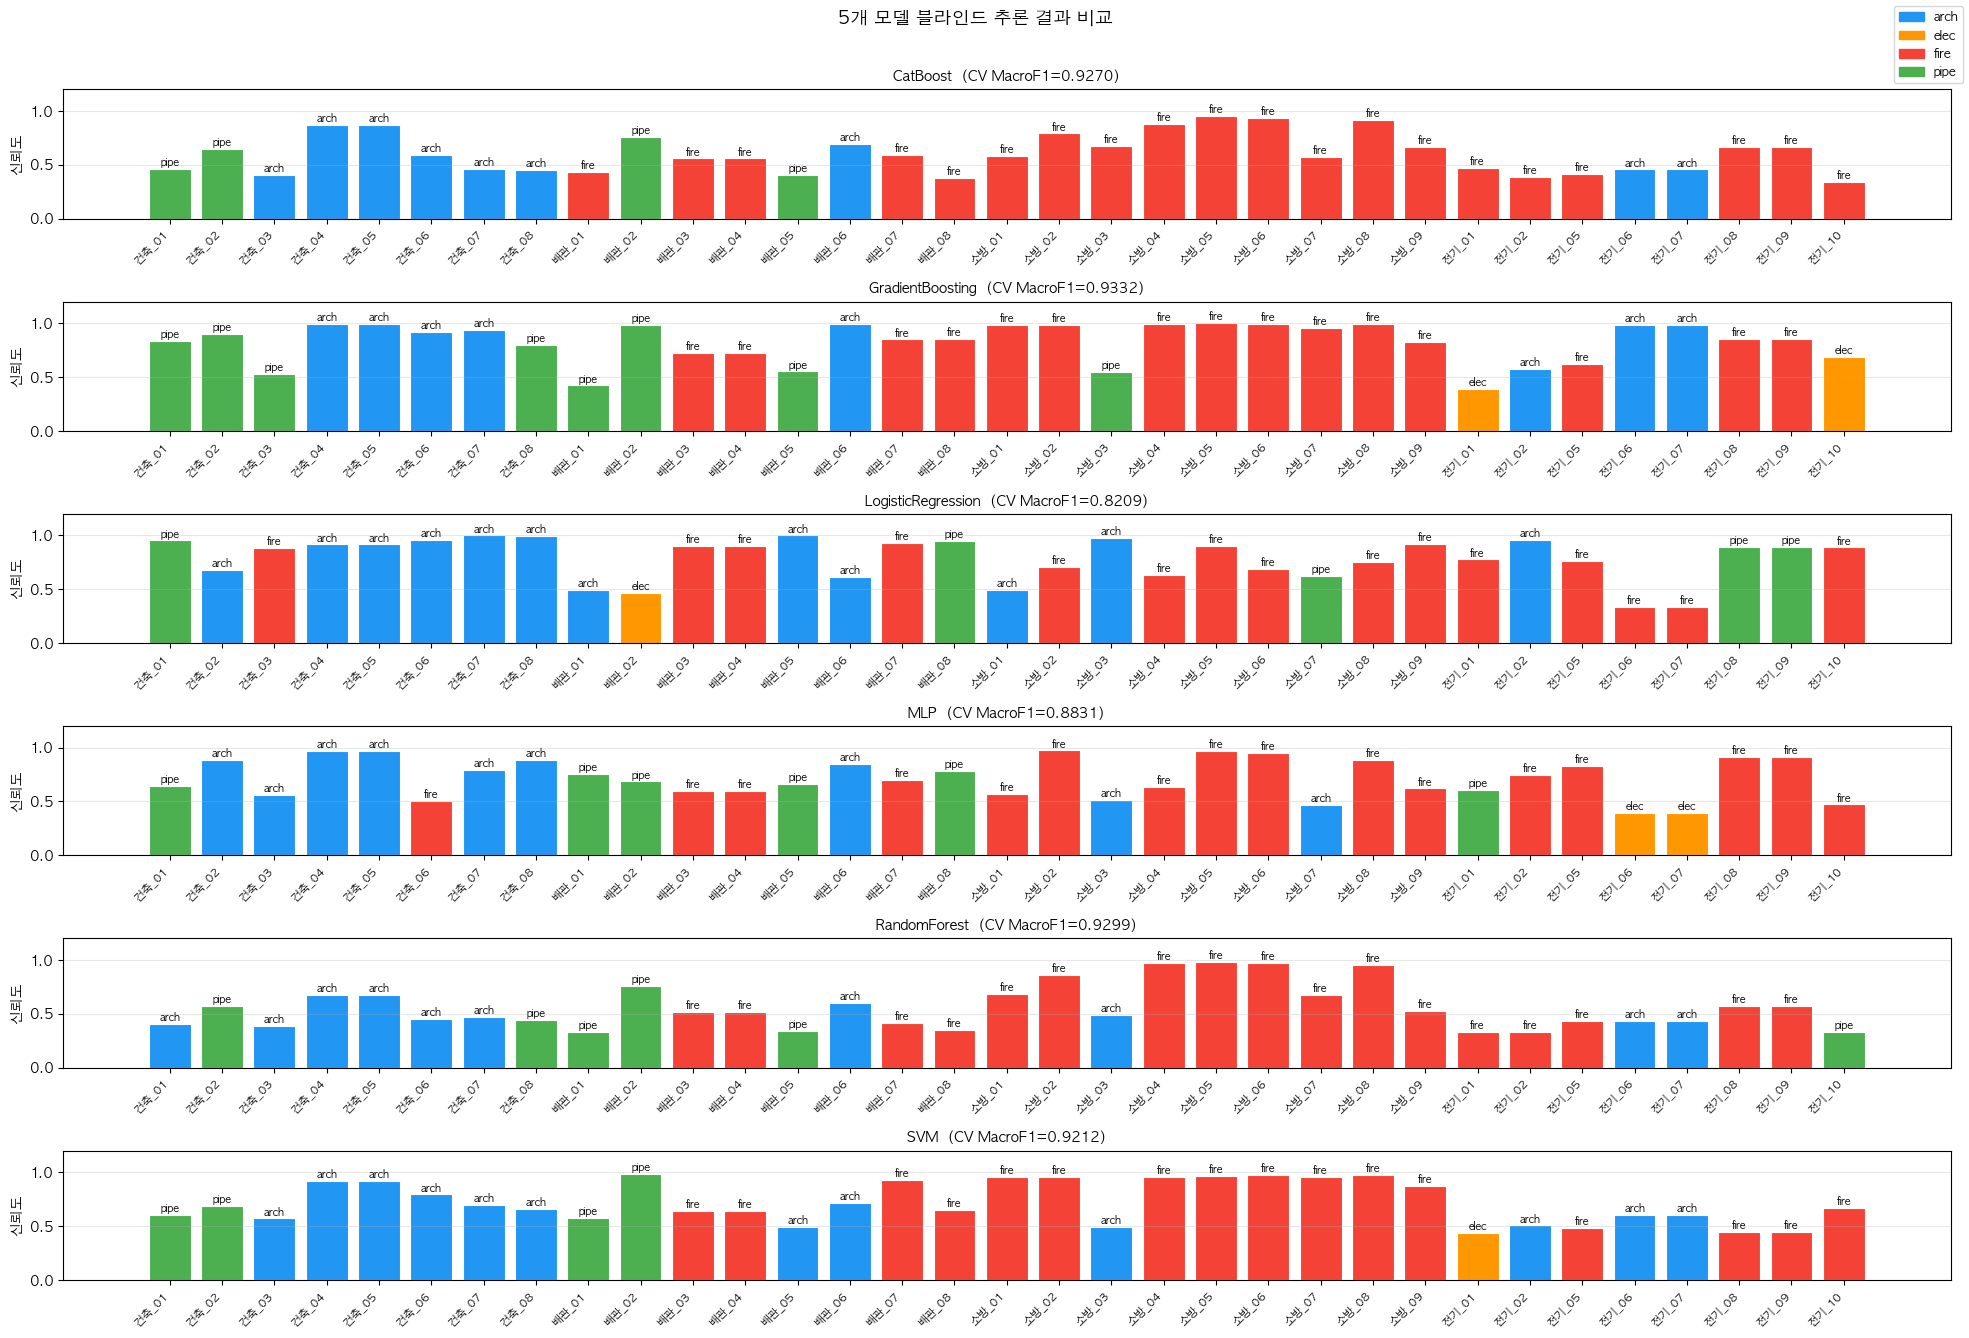

저장: /Users/gimdabin/SKN23-FINAL-2TEAM/docs/classifier/figures/final/blind_5model_comparison.png

=== 모델별 예측 분포 ===
  CatBoost               (CV=0.9270):  arch:9개  fire:20개  pipe:4개
  GradientBoosting       (CV=0.9332):  arch:8개  elec:2개  fire:15개  pipe:8개
  LogisticRegression     (CV=0.8209):  arch:12개  elec:1개  fire:15개  pipe:5개
  MLP                    (CV=0.8831):  arch:9개  elec:2개  fire:16개  pipe:6개
  RandomForest           (CV=0.9299):  arch:10개  fire:17개  pipe:6개
  SVM                    (CV=0.9212):  arch:12개  elec:1개  fire:16개  pipe:4개


In [7]:
DOMAIN_COLORS = {'arch':'#2196F3','elec':'#FF9800','fire':'#F44336','pipe':'#4CAF50','ERR':'#9E9E9E'}

fig, axes = plt.subplots(len(model_names), 1,
                          figsize=(max(12, len(cad_records)*0.6), len(model_names)*2.2))
if len(model_names) == 1:
    axes = [axes]

for ax, model_name in zip(axes, model_names):
    preds = df[model_name].tolist()
    confs = df[f'{model_name}_conf'].tolist()
    colors = [DOMAIN_COLORS.get(p, '#9E9E9E') for p in preds]
    bars = ax.bar(range(len(preds)), confs, color=colors, edgecolor='white', linewidth=0.8)
    for i, (p, c) in enumerate(zip(preds, confs)):
        ax.text(i, c + 0.01, p, ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['파일명'].tolist(), rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('신뢰도')
    cv_f1 = meta['all_cv_models'].get(model_name, {}).get('macro_f1_mean', 0)
    ax.set_title(f'{model_name}  (CV MacroF1={cv_f1:.4f})', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=d) for d, c in DOMAIN_COLORS.items() if d!='ERR']
fig.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.suptitle('5개 모델 블라인드 추론 결과 비교', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

out = PROJECT_ROOT / 'docs/classifier/figures/final/blind_5model_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

# ── 모델별 예측 분포 ──
print('\n=== 모델별 예측 분포 ===')
for model_name in model_names:
    counts = df[model_name].value_counts().to_dict()
    dist = '  '.join(f'{d}:{n}개' for d, n in sorted(counts.items()))
    cv_f1 = meta['all_cv_models'].get(model_name, {}).get('macro_f1_mean', 0)
    print(f'  {model_name:<22} (CV={cv_f1:.4f}):  {dist}')
